In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration

In [70]:
sigma = 0.05
m = 400

In [71]:
def bump(x, mu):
    w = 0.075
    y = np.zeros_like(x)
    y[np.abs(x-mu)<w/2] = 1.0
    return y

In [72]:
def richardson_lucy(im_blur, sgm, num_iter=50, clip=True, filter_epsilon=None):
    psf_f = gaussian_f(sgm, m)    
    im_deconv = im_blur.copy()

    # Small regularization parameter used to avoid 0 divisions
    eps = 1e-12

    for _ in range(num_iter):
        blurred = convolve_f(im_deconv, psf_f) + eps
        if filter_epsilon:
            relative_blur = np.where(blurred < filter_epsilon, 0, im_blur / blurred)
        else:
            relative_blur = im_blur / blurred
        im_deconv *= convolve_f(relative_blur, psf_f)
    if clip:
        im_deconv[im_deconv > 1] = 1
        im_deconv[im_deconv < -1] = -1

    return im_deconv

In [73]:
def convolve_f(y, g_f):
#     # alternative with mode = "wrap"
#     y_smooth2 = gaussian_filter1d(y, sigma/dx, mode="wrap", cval=0, truncate=20)
#     print(np.allclose(y_smooth, y_smooth2))
    y_f = fft(y)
    y_f_smooth = y_f*g_f
    y_smooth = ifft(y_f_smooth)
    return y_smooth.real

def convolve_x():
    return convolve(y, psf, mode='same')

In [74]:
def gaussian(x, sigma, m, shift=True):
    # dont use cv2.getGaussianKernel(m, sigma)[:, 0], we need the gaussian to be centered at one single node!
    if shift:
        x_kernel = fftshift(x)
        offset = x_kernel[0]
    else:
        x_kernel = x
        offset = np.min(np.abs(x))  # or 0?
    A = 1/(m*sigma*(2*np.pi)**.5)
    return A * np.exp(-(x_kernel-offset)**2 / (2 * sigma**2))

def gaussian_f(sigma, m):
    # g_f = fft(g_x)
    # print(np.allclose(g_f, g_f2))
    # plt.plot(g_f, "bo")
    # plt.plot(g_f2, "r.")
    # plt.show()

    # Fourier Transform of the Gaussian by Konstantinos G. Derpanis
    f = np.fft.fftfreq(m, d=1/m)
    omega = 2*np.pi*f
    return np.exp(-omega**2*sigma**2/2)

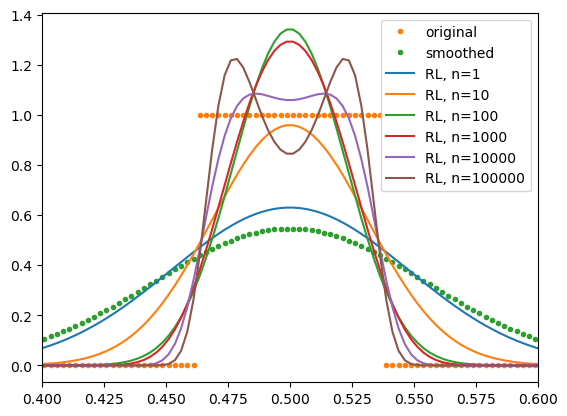

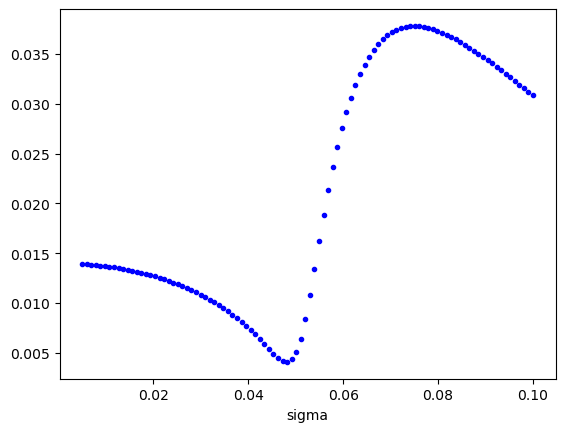

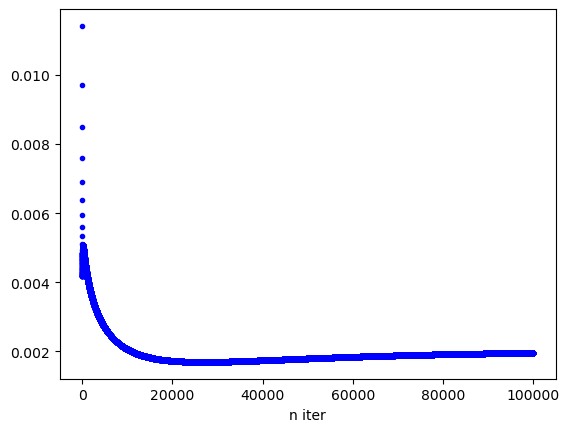

In [78]:
x = np.linspace(0, 1, m)
y = bump(x, 0.5)
#x_kernel = np.linspace(-.5, .5, 99, endpoint=True)
#psf = gaussian(x_kernel, sigma, len(x_kernel), shift=False)
#psf = gaussian(x-0.5, sigma, m, shift=False)
#psf = gaussian(x, sigma, m)

psf_f = gaussian_f(sigma, m)
y2 = convolve_f(y, psf_f)
e = np.empty(100,)
sgms = np.linspace(0.1*sigma, 2*sigma, 100)
for i, sgm in enumerate(sgms):
    y3 = richardson_lucy(y2, sgm, num_iter=100, clip=False, filter_epsilon=False)
    e[i] = np.mean((y3-y)**2)*.5
    
plt.plot(x, y, "C1.", label="original")
plt.plot(x, y2, "C2.", label="smoothed")
for n in [1, 10, 100, 1000, 10000, 100000]:
    y3 = richardson_lucy(y2, sigma, num_iter=n, clip=False, filter_epsilon=False)
    plt.plot(x, y3, "-", label="RL, n={:.0f}".format(n))
#plt.plot(x_kernel, psf, "C4.")
plt.legend()
plt.xlim(0.4, 0.6)
plt.show()

plt.plot(sgms, e, "b.")
plt.xlabel("sigma")
plt.show()

num_iter = 100000
e = np.empty(num_iter,)

im_blur = y2
psf_f = gaussian_f(sigma, m)    
im_deconv = im_blur.copy()
for k in range(num_iter):
    blurred = convolve_f(im_deconv, psf_f) + 1e-12
    relative_blur = im_blur / blurred
    im_deconv *= convolve_f(relative_blur, psf_f)
    e[k] = np.mean((im_deconv-y)**2)*.5
plt.plot(np.arange(num_iter), e, "b.")
plt.xlabel("n iter")
plt.show()